#Task 1.4: TWO ML MODELS
##Dataset
Diabetes Dataset

###Objective
Learn the supervised-learning workflow: define the problem, separate features and target, preprocess,
split data, train, predict, evaluate, inspect errors, and document limitations. Understand why regression
and classification use different model outputs and different evaluation metrics.



**REGRESSION**

In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print(X.shape)
print(y.shape)

(442, 10)
(442,)


**Train/Test Split**

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

 **Regression Model**

In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

 Prediction

In [4]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872]


**Metrics**

In [5]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 42.79409467959994
RMSE: 53.85344583676593
R2: 0.4526027629719195


**Actual vs Predicted**

In [6]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,219.0,139.547558
1,70.0,179.517208
2,202.0,134.038756
3,230.0,291.417029
4,111.0,123.789659
5,84.0,92.172347
6,242.0,258.232389
7,272.0,181.337321
8,94.0,90.224113
9,96.0,108.633759


In [7]:
comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

comparison.head(10)

,Actual,Predicted,Error
0,219.0,139.547558,79.452442
1,70.0,179.517208,-109.517208
2,202.0,134.038756,67.961244
3,230.0,291.417029,-61.417029
4,111.0,123.789659,-12.789659
5,84.0,92.172347,-8.172347
6,242.0,258.232389,-16.232389
7,272.0,181.337321,90.662679
8,94.0,90.224113,3.775887
9,96.0,108.633759,-12.633759


**CLASSIFICATION**

In [9]:
df = pd.read_csv("diabetes_data_upload.csv")

In [10]:
print(df.shape)
print(df.columns)
print(df.head())

(520, 17)
Index(['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class'],
      dtype='object')
   Age Gender Polyuria Polydipsia sudden weight loss weakness Polyphagia  \
0   40   Male       No        Yes                 No      Yes         No   
1   58   Male       No         No                 No      Yes         No   
2   41   Male      Yes         No                 No      Yes        Yes   
3   45   Male       No         No                Yes      Yes        Yes   
4   60   Male      Yes        Yes                Yes      Yes        Yes   

  Genital thrush visual blurring Itching Irritability delayed healing  \
0             No              No     Yes           No             Yes   
1             No             Yes      No           No              No   
2             No  

In [11]:
X = df.drop("class", axis=1)
y = df["class"]

**Categorical Data**

In [12]:
X = pd.get_dummies(X, drop_first=True)

In [13]:
y = y.map({
    "Positive": 1,
    "Negative": 0
})

In [14]:
print(df["class"].value_counts())

class
Positive    320
Negative    200
Name: count, dtype: int64


**Train/Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Classification Model**

In [16]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(max_iter=1000)

classifier.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**Prediction**

In [17]:
y_pred = classifier.predict(X_test)

print(y_pred[:10])

[0 1 1 0 0 1 1 0 1 0]


**Classification Metrics**

In [18]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Accuracy: 0.9423076923076923
Precision: 0.9833333333333333
Recall: 0.921875
F1: 0.9516129032258065


**Confusion Matrix**

In [22]:
import matplotlib.pyplot as plt

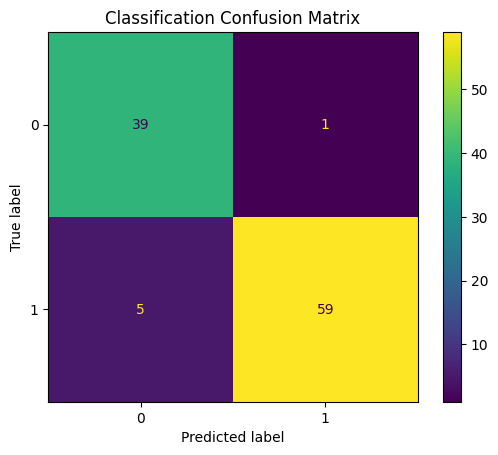

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Classification Confusion Matrix")
plt.show()

**Wrong Predictions**

In [21]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Correct"] = (
    comparison["Actual"] == comparison["Predicted"]
)

comparison.head(20)

,Actual,Predicted,Correct
0,0,0,True
1,1,1,True
2,1,1,True
3,0,0,True
4,0,0,True
5,1,1,True
6,1,1,True
7,0,0,True
8,1,1,True
9,0,0,True


In [24]:
wrong_predictions = comparison[
    comparison["Correct"] == False
]

wrong_predictions.head(10)

,Actual,Predicted,Correct
16,1,0,False
17,1,0,False
68,1,0,False
69,1,0,False
91,0,1,False
93,1,0,False


# Model Limitations


## Limitations

The models provide predictions based on the available dataset and selected features.
Performance metrics should be interpreted in the context of the dataset and test split.
The models may make incorrect predictions, so error analysis is important.